In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1)

In [2]:
df = pd.read_csv('Fish.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [4]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [5]:
df_Perch = df[df['Species']=='Perch']


In [6]:
df_Perch

,Species,Weight,Length1,Length2,Length3,Height,Width
72,Perch,5.9,7.5,8.4,8.8,2.1120,1.4080
73,Perch,32.0,12.5,13.7,14.7,3.5280,1.9992
74,Perch,40.0,13.8,15.0,16.0,3.8240,2.4320
75,Perch,51.5,15.0,16.2,17.2,4.5924,2.6316
76,Perch,70.0,15.7,17.4,18.5,4.5880,2.9415
77,Perch,100.0,16.2,18.0,19.2,5.2224,3.3216
78,Perch,78.0,16.8,18.7,19.4,5.1992,3.1234
79,Perch,80.0,17.2,19.0,20.2,5.6358,3.0502
80,Perch,85.0,17.8,19.6,20.8,5.1376,3.0368
81,Perch,85.0,18.2,20.0,21.0,5.0820,2.7720


# 2)

### a) Y - Weight, X - Width

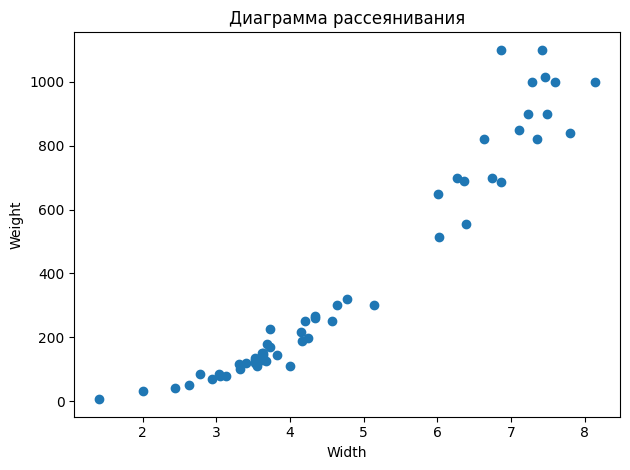

In [72]:
plt.scatter( df_Perch['Width'],df_Perch['Weight'])
plt.xlabel('Width')
plt.ylabel('Weight')
plt.title('Диаграмма рассеянивания')
plt.tight_layout()
plt.show()

### b)

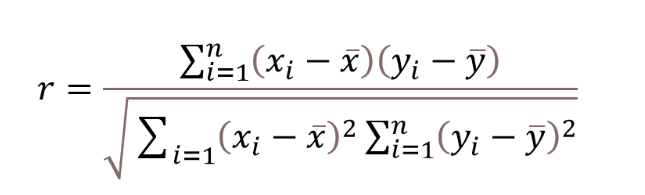

In [18]:
def corr_X_Y(X,Y):
    X_val = X.values
    Y_val = Y.values

    avg_X = np.mean(X_val)
    avg_Y = np.mean(Y_val)

    X_2 = (avg_X - X_val)**2
    Y_2 = (avg_Y - Y_val)**2

    sum_X_2 = X_2.sum()
    sum_Y_2 = Y_2.sum()

    mul_avg_X_Y = ((avg_X-X_val)*(avg_Y - Y_val)).sum()

    rXY = (mul_avg_X_Y)/np.sqrt(sum_X_2*sum_Y_2)

    return rXY






In [68]:
rxy = corr_X_Y(df_Perch['Width'],df_Perch['Weight'])
rxy

0.9639433246031044

### c)

In [58]:
def linear_regression(X,y):
    w1 = np.sum((y-np.mean(y))*(X-np.mean(X)))/np.sum((X-np.mean(X))**2)
    w0 = np.mean(y) - np.mean(X)*w1

    return w0+w1*X , w0, w1
 

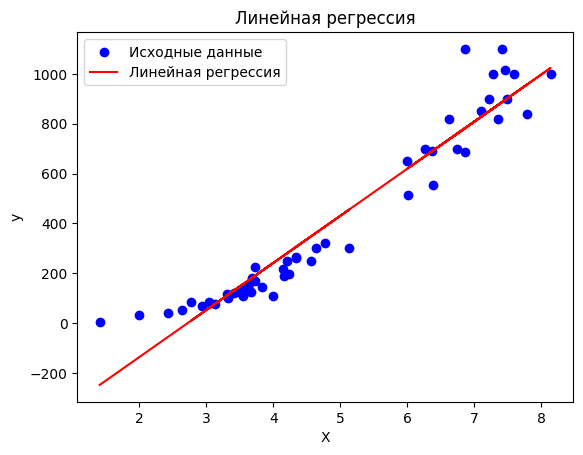

w0: -513.845118458206, w1: 188.81935665254824


In [69]:
X = df_Perch['Width'].values
y = df_Perch['Weight'].values

new_y , w0,w1= linear_regression(X, y)

plt.scatter(X, y, color='blue', label='Исходные данные')
plt.plot(X, new_y, color='red', label='Линейная регрессия')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Линейная регрессия')
plt.legend()
plt.show()

print(f'w0: {w0}, w1: {w1}')

### d)

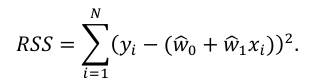

In [70]:
RSS = np.sum((y - (w0+w1*X))**2)
RSS

470631.64657371293

### e)

In [71]:
TSS = np.sum((y -np.mean(y))**2)
R2 = 1 - RSS/TSS
R2

0.9291867330468856

### 3)

### a)

In [146]:
def linear_regression_N2(X1,X2, y, learning_rate = 0.0001, epochs = 10000):

  w0 = np.random.uniform(-400,400)
  w1 = np.random.uniform(-400,400)
  w2 = np.random.uniform(-400,400)

  for _ in range(epochs):
    y_predict = w0 + w1*X1 + w2*X2
    
    dw0 = -2*np.sum(y-y_predict)
    dw1 = -2*np.sum((y-y_predict)*X1)
    dw2 = -2*np.sum((y-y_predict)*X2)

    w0 -=learning_rate*dw0
    w1 -=learning_rate*dw1
    w2 -=learning_rate*dw2

  f = w0 + w1*X1 + w2*X2

  return w0, w1, w2, f

In [147]:
X1 = df_Perch['Width'].values
X2 = df_Perch['Height'].values
y = df_Perch['Weight'].values

w0, w1, w2, f = linear_regression_N2(X1,X2,y)



print(f'w0: {w0}, w1: {w1}, w2: {w2}')

w0: -535.985695483372, w1: 69.6913699634414, w2: 74.7265200496223


### b)

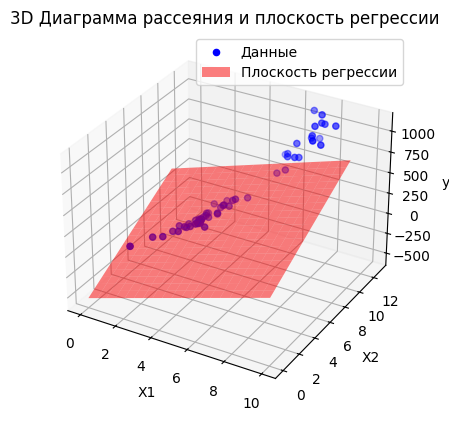

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2, y, color='blue', label='Данные')

X1_grid, X2_grid = np.meshgrid(np.linspace(0, 10, 20), np.linspace(0, 10, 20))
y_grid = w0 + w1 * X1_grid + w2 * X2_grid
ax.plot_surface(X1_grid, X2_grid, y_grid, alpha=0.5, color='red', label='Плоскость регрессии')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title('3D Диаграмма рассеяния и плоскость регрессии')

plt.legend()
plt.show()

### c)

In [149]:
RSS = np.sum((y - (w0+w1*X1+w2*X2))**2)
RSS

384478.1428558838

### d)

In [150]:
TSS = np.sum((y -np.mean(y))**2)
R2 = 1 - RSS/TSS
R2

0.9421497607185941

### e)